In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

from analysis.topology import get_topology_from_mol
from analysis.dihedrals import get_dihedrals

In [ ]:
# sample_path = "../data/eval_markovian_smaller_steps_and_upweighted_dynamic_loss/dynamic_500"
sample_path = "../data/eval_markovian/dynamic_900"
mol_path = Path(sample_path) / "molecule_000.mol"


# Get topology
top = get_topology_from_mol(mol_path)
print([a for a in top.atoms])
# Get dihedrals
phi_atoms = [1, 3, 4, 6]
psi_atoms = [3, 4, 6, 8]
dihedrals = {}
for coord_file_path in [sample_path]:
    dihedrals["phi"], dihedrals["psi"] = get_dihedrals(coord_file_path, top, phi_atoms, psi_atoms, save_pdb=True, file_type="mol")


[UNL1-C1, UNL1-C2, UNL1-O1, UNL1-N1, UNL1-C3, UNL1-C4, UNL1-C5, UNL1-O2, UNL1-N2, UNL1-C6]


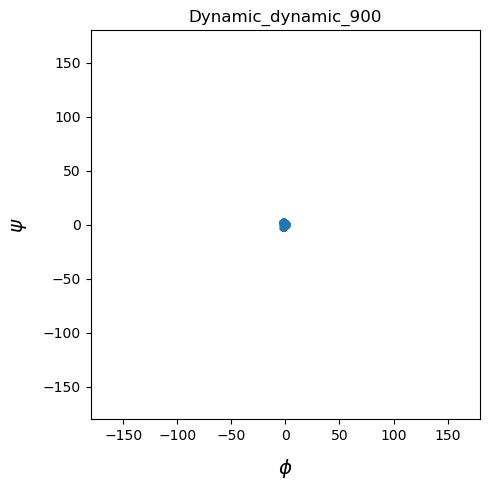

In [6]:
plt.figure(figsize=(5, 5))

plt.scatter(dihedrals["phi"], dihedrals["psi"], s=10)
plt.xlabel(r"$\phi$", fontsize="x-large", labelpad=10)
plt.ylabel(r"$\psi$", fontsize="x-large", labelpad=10)
plt.title(f"Dynamic_{sample_path.split('/')[-1]}")
plt.xlim(-180, 180)
plt.ylim(-180, 180)


plt.tight_layout()
plt.show()